In [ ]:
#Necessary Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder

## Brief description of each of the libraries and modules mentioned in the above codeblock:

1. **`pandas`**  
   - **Purpose**: Used for data manipulation and analysis.  
   - **Use Case**: Works with structured data through **DataFrames** and **Series**.  
   - Example: `pd.read_csv()` to read CSV files.

2. **`numpy`**  
   - **Purpose**: Provides support for large, multi-dimensional arrays and matrices.  
   - **Use Case**: Ideal for numerical computations and mathematical operations.  
   - Example: `np.array()` to create arrays.

3. **`matplotlib.pyplot`**  
   - **Purpose**: A plotting library to create static, interactive, and animated visualizations.  
   - **Use Case**: Used to plot graphs like line plots, histograms, etc.  
   - Example: `plt.plot()` for line plots.

4. **`seaborn`**  
   - **Purpose**: Builds on Matplotlib for attractive and informative statistical graphics.  
   - **Use Case**: Useful for visualizing data distributions, relationships, and heatmaps.  
   - Example: `sns.heatmap()` for correlation heatmaps.

5. **`statsmodels.api`**  
   - **Purpose**: Provides tools for statistical models and hypothesis testing.  
   - **Use Case**: Used to fit models like OLS (Ordinary Least Squares).  
   - Example: `sm.OLS()` for linear regression.

6. **`sklearn.linear_model.LinearRegression`**  
   - **Purpose**: Part of Scikit-Learn; used for building linear regression models.  
   - **Use Case**: Useful for predicting continuous variables.  
   - Example: `LinearRegression().fit(X, y)` to fit the model.

7. **`statsmodels.formula.api`**  
   - **Purpose**: Provides a formula-based interface to Statsmodels.  
   - **Use Case**: Allows model creation using R-like formulas (e.g., `'y ~ X'`).  
   - Example: `smf.ols()` for linear regression using formulas.

8. **`sklearn.preprocessing.LabelEncoder`**  
   - **Purpose**: Used to convert categorical data into numeric labels.  
   - **Use Case**: Encodes target or feature variables before feeding them into machine learning models.  
   - Example: `LabelEncoder().fit_transform()` to encode labels.

These libraries cover a wide range of data science tasks, from data handling and visualization to model building and preprocessing.

# About the Dataset

In [ ]:
df = pd.read_csv("https://drive.google.com/uc?id=1TFKoSpixNIMF9HDc_ug9EP3cYQnl3Bf6&export=download")
df

,Participant ID,Age,Gender,SES,Service Type,Visit Frequency,Step Frequency (steps/min),Stride Length (m),Joint Angle (°),EMG Activity,Patient Satisfaction (1-10),Quality of Life Score
0,1,56,F,4,Rehab,Weekly,85,0.54,17.99,Low,1,57
1,2,69,M,1,Preventive,Yearly,80,0.70,13.05,Moderate,8,94
2,3,46,M,4,Rehab,Yearly,81,0.57,29.85,Moderate,4,66
3,4,32,F,1,Consultation,Weekly,66,0.78,28.54,Moderate,9,66
4,5,60,M,3,Preventive,Weekly,73,0.84,20.80,High,5,98
...,...,...,...,...,...,...,...,...,...,...,...,...
342,343,24,M,3,Preventive,Yearly,92,0.67,27.45,Low,3,58
343,344,20,F,3,Rehab,Monthly,72,0.83,26.84,Low,4,81
344,345,34,F,3,Preventive,Yearly,89,0.90,13.72,Low,7,60
345,346,50,M,3,Preventive,Weekly,92,0.96,26.05,Moderate,3,57


The dataset is a **health-related study** with various features describing participants.

### **Dataset Overview:**
- **Number of Participants:** 347  
- **Features and their Summary:**
  - **Participant ID:** Unique identifier for each participant (ranging from 1 to 347).
  - **Age:** Participant age, ranging from 18 to 69 years, with a mean of 43.4 years.
  - **SES (Socioeconomic Status):** Categorical data (1 to 4), indicating participants' economic background.
  - **Step Frequency (steps/min):** Average number of steps taken per minute, ranging from 60 to 99, with an average of 80.1 steps/min.
  - **Stride Length (m):** Distance covered per step, varying from 0.5m to 1m, with a mean of 0.75m.
  - **Joint Angle (°):** Average joint angle measured in degrees, with a mean of 20.06° and a max of 29.97°.
  - **Patient Satisfaction (1-10):** Participant’s self-reported satisfaction score, ranging from 1 to 10, with an average of 5.21.
  - **Quality of Life Score:** Score reflecting participants' quality of life, varying from 50 to 99, with an average of 74.2.

### **General Observations:**
- **Participants' Ages** are evenly distributed, with a median age of 43 years.
- **Satisfaction and Quality of Life Scores** show variability, with average values near the midpoints.
- There is a healthy variation in **stride length and step frequency**, indicating differences in physical activity.
- **SES** is likely an indicator of economic class, which might have a relationship with other health factors in the dataset.

**AIM:**   
To analyse and apply the concepts of probabbility and statistics to the above mentioned dataset that could be useful for **analyzing the relationship between physical activity, joint angles, and quality of life**, possibly with insights into how socioeconomic status and patient satisfaction influence health outcomes.

In [ ]:
#changing column names for convenience
names = ['ID', 'age', 'Gender', 'SES', 'Service_Type',
       'Visit_Fre', 'Step_Fre', 'Stride_Length_m',
       'Joint_Angle', 'EMG_activity', 'P_Satisfaction',
       'QL_Score']
lw_col = [name.lower() for name in names]

In [ ]:
df.columns = lw_col
df.head()

,id,age,gender,ses,service_type,visit_fre,step_fre,stride_length_m,joint_angle,emg_activity,p_satisfaction,ql_score
0,1,56,F,4,Rehab,Weekly,85,0.54,17.99,Low,1,57
1,2,69,M,1,Preventive,Yearly,80,0.70,13.05,Moderate,8,94
2,3,46,M,4,Rehab,Yearly,81,0.57,29.85,Moderate,4,66
3,4,32,F,1,Consultation,Weekly,66,0.78,28.54,Moderate,9,66
4,5,60,M,3,Preventive,Weekly,73,0.84,20.80,High,5,98


In [ ]:
df.describe()

,id,age,ses,step_fre,stride_length_m,joint_angle,p_satisfaction,ql_score
count,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000
mean,174.000000,43.374640,2.357349,80.123919,0.751499,20.057378,5.213256,74.195965
std,100.314505,15.177304,1.129848,11.257582,0.143221,5.807653,2.833643,13.949400
min,1.000000,18.000000,1.000000,60.000000,0.500000,10.060000,1.000000,50.000000
25%,87.500000,31.000000,1.000000,71.000000,0.620000,15.065000,3.000000,62.000000
50%,174.000000,43.000000,2.000000,81.000000,0.760000,20.190000,5.000000,74.000000
75%,260.500000,56.000000,3.000000,90.000000,0.860000,25.220000,8.000000,86.000000
max,347.000000,69.000000,4.000000,99.000000,1.000000,29.970000,10.000000,99.000000


* The mean age is 43.37 years, with a standard deviation of 15.18 years.
* The average step frequency is 80.12 steps per minute, and the average stride length is 0.75 meters.
* The mean satisfaction score is 5.21 out of 10, and the mean QL score is 74.20.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               347 non-null    int64  
 1   age              347 non-null    int64  
 2   gender           347 non-null    object 
 3   ses              347 non-null    int64  
 4   service_type     347 non-null    object 
 5   visit_fre        347 non-null    object 
 6   step_fre         347 non-null    int64  
 7   stride_length_m  347 non-null    float64
 8   joint_angle      347 non-null    float64
 9   emg_activity     347 non-null    object 
 10  p_satisfaction   347 non-null    int64  
 11  ql_score         347 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 32.7+ KB


* Numerical Variables: `[age, ses, step_fre, stride_length_m, joint_angle, p_satisfaction, ql_score]`
* Categorical variables: `[gender, service_type, visit_fre, emg_activity]`

## **DATA Cleaning and Preprocessing**

To ensure the dataset is ready for analysis, we have performed the following **data cleaning and preprocessing steps**:

1. **Handling Missing Values:**
   - Checking if any of the columns contain **missing values**.
   - If found, we considered using techniques like **mean/median imputation** or removing rows with missing data.
   - We could not find any missing data in the original dataset.

2. **Outlier Detection:**
   - Use visualizations (e.g., boxplots) to **identify outliers** in features like **Step Frequency, Joint Angle, or Quality of Life Score**.
   - Decide whether to **remove or cap** the outliers to maintain data quality.
   - We have performed analysis for both the scenario's with and without outliers.

3. **Data Type Conversion:**
   - To ensure all columns have the **correct data types** (e.g., IDs should be integers, and categorical columns like SES should use appropriate encodings).
   - For categorical columns, we have used Labelencoder() function from preprocessing module of the sklearn library.


4. **Removing Duplicates:**
   - To check for **duplicate rows** using the `drop_duplicates()` function and remove them to avoid redundancy.

5. **Handling Outliers in Satisfaction and Quality of Life Scores:**
   - Since these scores are subjective, it’s worth examining if **extreme values** are valid or need correction.


In [ ]:
#Handling Missing Values:
def FindingNullDataframe(df):
    for i in df:
        number_null_rows=df[df[i].isna()]
        return number_null_rows

FindingNullDataframe(df) # No null-values were returned

,id,age,gender,ses,service_type,visit_fre,step_fre,stride_length_m,joint_angle,emg_activity,p_satisfaction,ql_score


In [ ]:
#Dropping Unused Columns from Dataframe
df.drop(labels='id',axis=1,inplace=True)

In [ ]:
def Finding_unique_values(df):
    for i in df:
        print(df[i].unique())
def Finding_Value_Counts(df):
    for i in df:
        print(df[i].value_counts())

Finding_Value_Counts(df)
Finding_unique_values(df)

age
50    12
41    12
56    11
52    11
61    11
19    11
69    10
49    10
65     9
66     9
25     9
45     9
20     9
26     8
42     8
54     8
24     8
18     8
32     8
28     8
43     8
58     7
31     7
37     7
33     7
59     7
53     7
57     7
35     6
46     6
23     6
21     6
40     6
68     6
36     5
38     5
44     5
34     5
64     5
39     5
62     5
47     4
22     4
29     4
51     3
55     3
67     3
30     3
48     2
60     2
27     1
63     1
Name: count, dtype: int64
gender
F    184
M    163
Name: count, dtype: int64
ses
1    107
3     83
2     83
4     74
Name: count, dtype: int64
service_type
Preventive      119
Consultation    117
Rehab           111
Name: count, dtype: int64
visit_fre
Weekly     120
Yearly     116
Monthly    111
Name: count, dtype: int64
step_fre
88    17
72    15
74    14
91    13
93    13
76    12
84    12
77    12
94    11
62    11
89    11
83    11
70    10
92    10
79     9
98     9
81     9
64     8
96     8
63     8
67     8
73     

In [ ]:
#Data Type Conversion from categorical to numerical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['gender']=label_encoder.fit_transform(df['gender'])
df['service_type']=label_encoder.fit_transform(df['service_type'])
df['visit_fre']=label_encoder.fit_transform(df['visit_fre'])
df['emg_activity']=label_encoder.fit_transform(df['emg_activity'])

In [ ]:
df

,age,gender,ses,service_type,visit_fre,step_fre,stride_length_m,joint_angle,emg_activity,p_satisfaction,ql_score
0,56,0,4,2,1,85,0.54,17.99,1,1,57
1,69,1,1,1,2,80,0.70,13.05,2,8,94
2,46,1,4,2,2,81,0.57,29.85,2,4,66
3,32,0,1,0,1,66,0.78,28.54,2,9,66
4,60,1,3,1,1,73,0.84,20.80,0,5,98
...,...,...,...,...,...,...,...,...,...,...,...
342,24,1,3,1,2,92,0.67,27.45,1,3,58
343,20,0,3,2,0,72,0.83,26.84,1,4,81
344,34,0,3,1,2,89,0.90,13.72,1,7,60
345,50,1,3,1,1,92,0.96,26.05,2,3,57


## Summary Statistics of the Target Column - 'ql_score' (Quality of life score)

In [ ]:
df.groupby('gender')['ql_score'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
0,184.0,74.239130,13.683279,50.0,62.75,74.0,85.25,99.0
1,163.0,74.147239,14.285983,50.0,62.00,73.0,86.00,99.0


In [ ]:
print(f"The mode of the ql_score column: {df['ql_score'].mode().tolist()}.")

The mode of the ql_score column: [62].


* The mean suggests that the average quality of life score is around 74, with a standard deviation of 13.95 indicating moderate variability.
* The median of 74 is close to the mean, suggesting a relatively symmetric distribution, meaning that the data does not have significant skewness. In a symmetric distribution, the average, median, and mode often align, indicating that extreme values (outliers) are not heavily influencing the average score. In this case mean = median != mode (74 = 74 != 62). Hence we can expect the influence of the outliers on the distribution of this column.
* The minimum and maximum values indicate the range of scores, with 50 being the lowest and 99 being the highest.
* The quartiles provide information about the spread of the data, with 50% of the scores falling between 62 and 86.

## Visualization of Data

<Axes: xlabel='Count', ylabel='gender'>

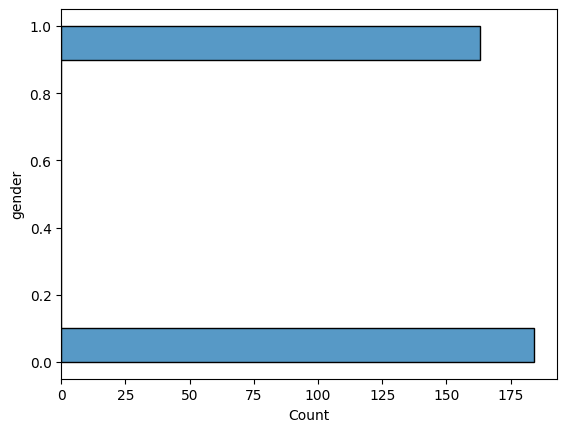

In [ ]:
sns.histplot(y=df['gender'])

**Interpretation of the above histogram (Gender)**
* The x-axis represents the count of observations for each gender category, while the y-axis indicates the gender categories themselves.
* The histogram shows that there are approximately 175 observations for the first gender category and 150 observations for the second gender category.
* The distribution appears to be relatively balanced, with no significant differences in the counts between the two categories.

<Axes: xlabel='age', ylabel='Count'>

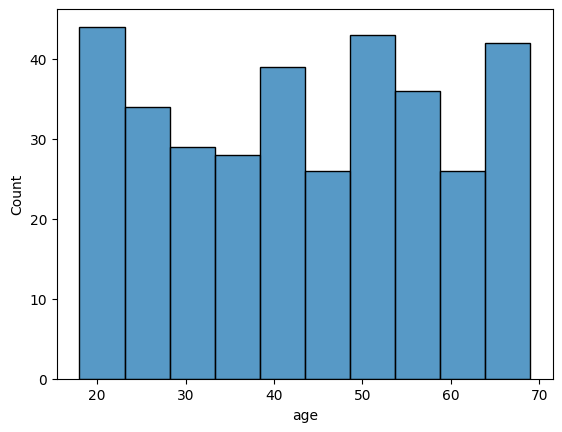

In [ ]:
sns.histplot(x=df['age'])

**Interpretation of the above histogram (Age)**
* The x-axis represents the age range, while the y-axis indicates the count of observations within each age range.
* The histogram shows that the majority of individuals in the dataset are between 20 and 30 years old, with a smaller number of individuals in the older age groups.
* The distribution appears to be slightly skewed to the right, indicating that there are a few individuals in the dataset who are significantly older than the majority of the sample.

<Axes: xlabel='visit_fre', ylabel='Count'>

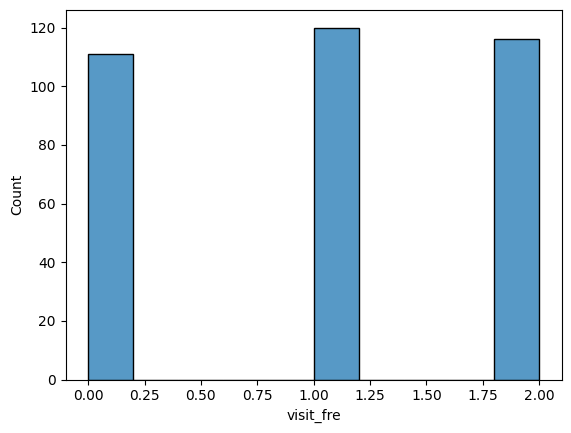

In [ ]:
sns.histplot(x=df['visit_fre'])

**Interpretation of the above histogram (visit_fre)**
* The x-axis represents the frequency of visits, while the y-axis indicates the count of observations within each visit frequency category.
* The histogram shows that the majority of individuals in the dataset have a visit frequency of 1, with smaller numbers of individuals having visit frequencies of 0 and 2.
* The distribution appears to be relatively balanced, with no significant differences in the counts between the visit frequency categories.

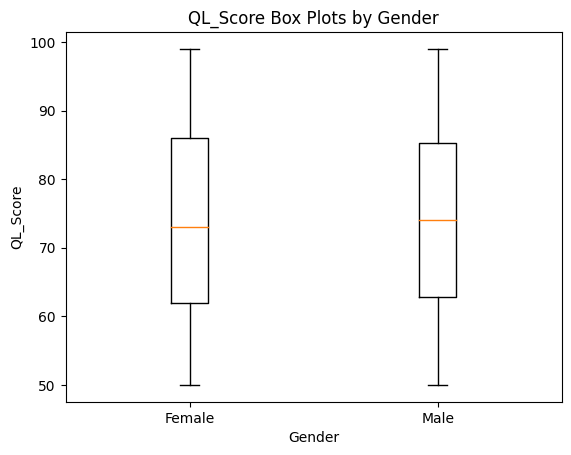

In [ ]:
#Checking for outliers in QL_Score

plt.boxplot(df['ql_score'][df['gender']==1], positions=[1], labels= ['Female'])
plt.boxplot(df['ql_score'][df['gender']==0], positions=[2], labels= ['Male'])

plt.title('QL_Score Box Plots by Gender')
plt.xlabel('Gender')
plt.ylabel('QL_Score')
plt.show()

**Interpretation of the above Box-Plot (Gender)**
* The above box plot compares the distribution of the ql_score variable between two gender categories: female and male.
* The x-axis represents the gender categories, while the y-axis indicates the ql_score values.
* The box plot shows the median ql_score for each gender category, as well as the interquartile range (IQR) and potential outliers.
* The median ql_score for females appears to be slightly higher than that for males, but the overall distributions are quite similar, with overlapping IQRs and a few potential outliers in both groups.

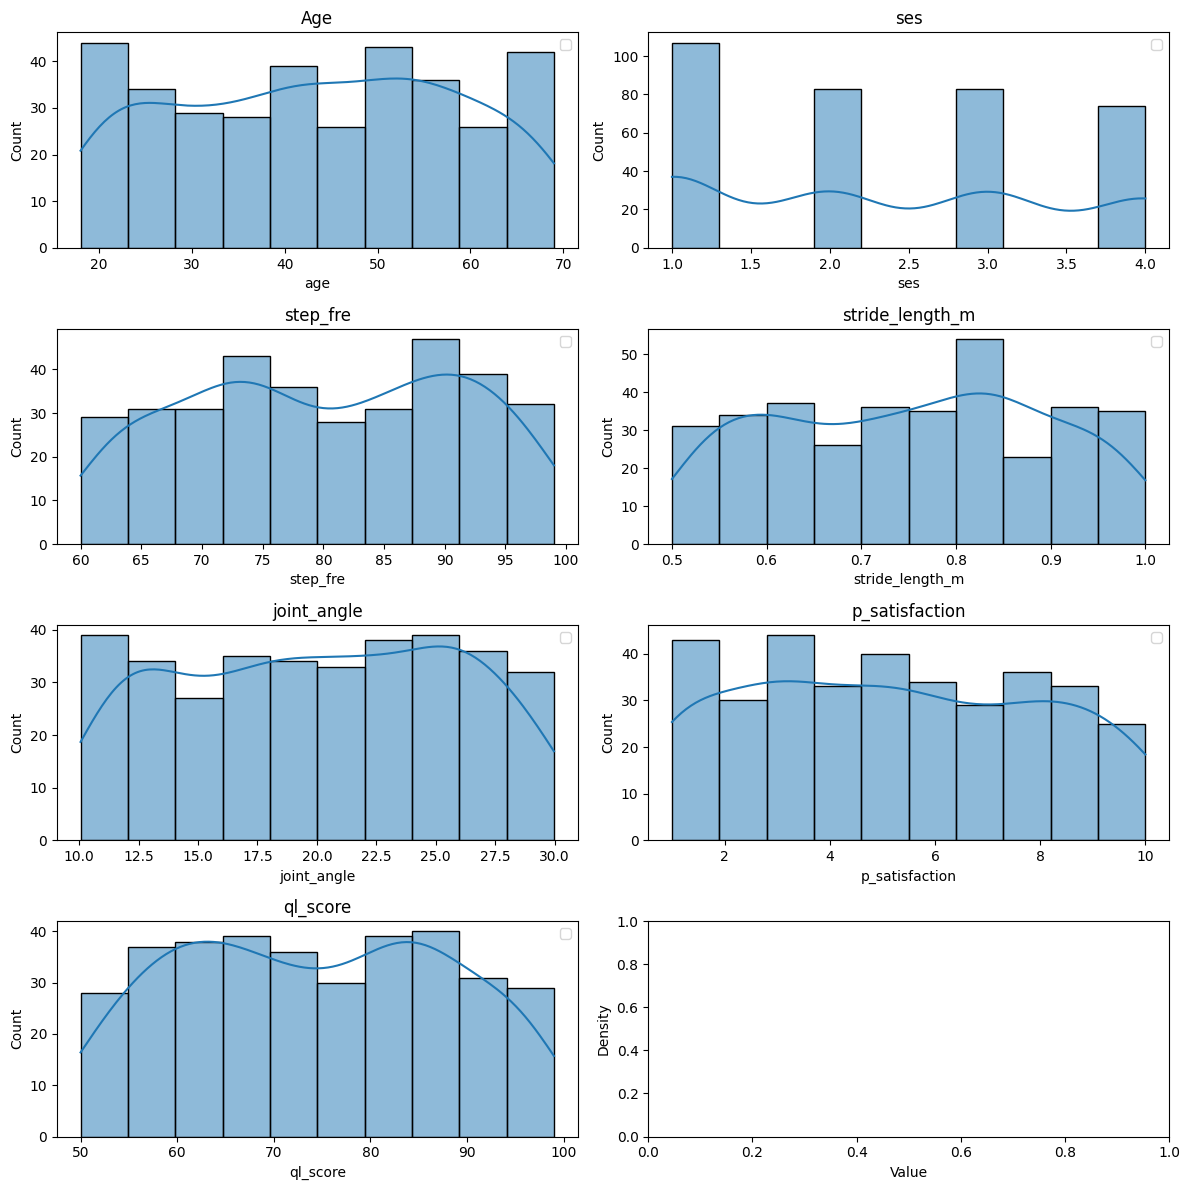

In [ ]:
#overall understanding of the distribution of each column by plotting frequency distribution
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

sns.histplot(df['age'], ax=axes[0], kde= True)
axes[0].set_title('Age')
axes[0].legend()

sns.histplot(df['ses'], ax=axes[1], kde= True)
axes[1].set_title('ses')
axes[1].legend()

sns.histplot(df['step_fre'], ax=axes[2], kde= True)
axes[2].set_title('step_fre')
axes[2].legend()

sns.histplot(df['stride_length_m'], ax=axes[3], kde= True)
axes[3].set_title('stride_length_m')
axes[3].legend()

sns.histplot(df['joint_angle'], ax=axes[4], kde= True)
axes[4].set_title('joint_angle')
axes[4].legend()

sns.histplot(df['p_satisfaction'], ax=axes[5], kde= True)
axes[5].set_title('p_satisfaction')
axes[5].legend()

sns.histplot(df['ql_score'], ax=axes[6], kde= True)
axes[6].set_title('ql_score')
axes[6].legend()


plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

##**Interpretation of the above subplots:**

**General Observations:**

* The plot consists of eight subplots, each representing a different variable.
* The x-axis labels indicate the variable name, while the y-axis labels represent the count or density.
* The blue bars represent the frequency or density of the data points within each bin.
* The blue line overlaid on the histograms is likely a density curve, providing a smoothed representation of the distribution.

**Specific Observations for Each Subplot:**

* **Age:**
  - The distribution is skewed to the right, indicating that there are more older individuals in the sample.
* **ses:**
  - The distribution appears to be approximately uniform, with no clear peaks or valleys.
* **step_fre:**
  - The distribution is skewed to the left, indicating that there are more individuals with lower step frequencies.
  - The peak of the distribution is around 70-75 steps per minute.
* **stride_length_m:**
  - The distribution is skewed to the right, indicating that there are more individuals with longer stride lengths.
  - The peak of the distribution is around 0.8 meters.
* **joint_angle:**
  - The distribution is approximately normal, with a peak around 20 degrees.
* **p_satisfaction:**
  - The distribution is skewed to the left, indicating that there are more individuals with lower satisfaction.
* **ql_score:**
  - The distribution is skewed to the right, indicating that there are more individuals with higher quality of life scores.
  - The peak of the distribution is around 80.

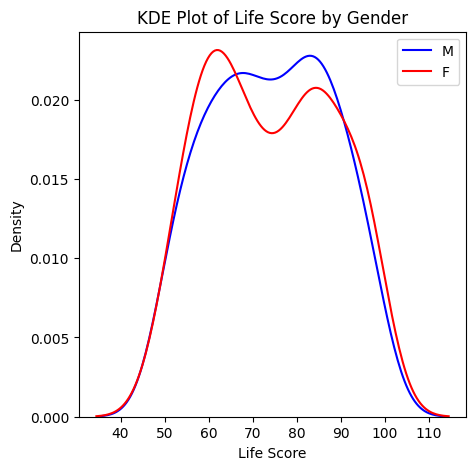

In [ ]:
plt.figure(figsize=(5, 5))

# KDE plot for men
sns.kdeplot(df[df['gender'] == 0]['ql_score'], color='blue', label='M')

# KDE plot for women
sns.kdeplot(df[df['gender'] == 1]['ql_score'], color='red', label='F')

plt.xlabel('Life Score')
plt.ylabel('Density')
plt.title('KDE Plot of Life Score by Gender')
plt.legend()
plt.show()

**Interpretation of the KDE Plot of Life Score by Gender**  
The plot presents kernel density estimates (KDE) of life scores for two gender groups: Male (M)(0) and Female (F)(1). KDEs provide a smoothed representation of the probability density function, allowing for a better understanding of the distribution of life scores within each gender.

* Both male and female life scores appear to follow a similar distribution, with a bell-shaped curve. This suggests that the majority of individuals in both groups have life scores around the central tendency.
* The distribution for females is slightly wider than that for males, indicating a greater spread or variability in life scores among females.
* The peak of the KDE for females is slightly to the right of the peak for females. This suggests that, on average, males tend to have slightly higher life scores than females.
* There is a significant overlap between the two KDEs, particularly in the middle range of life scores. This indicates that a considerable portion of individuals in both genders have similar life scores.

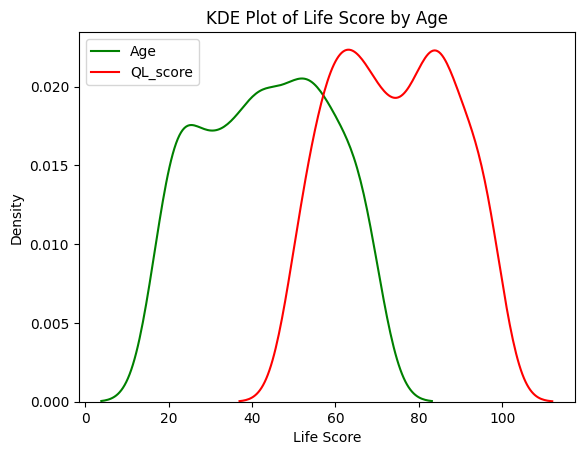

In [ ]:
sns.kdeplot(df['age'], color = 'green', label = 'Age')
sns.kdeplot(df['ql_score'], color = 'red', label = 'QL_score')
plt.xlabel('Life Score')
plt.ylabel('Density')
plt.title('KDE Plot of Life Score by Age')
plt.legend()
plt.show()

* The above kde plot does not represents the distribution of the mentioned variables due to diffrenent in scales of the axis.
* To rectify, we would equalize the scales by converting the data fields in to z scores.
*Formula = Z-score = (Age - Mean of age) / Std of Age


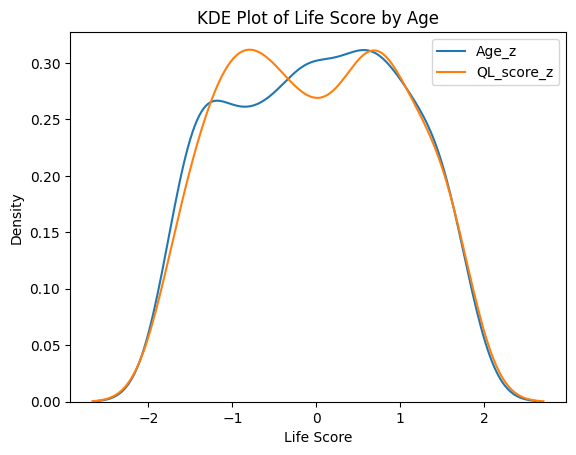

In [ ]:
age_z_score = [(age-df['age'].mean())/df['age'].std() for age in df['age']]
ql_z_score = [(age-df['ql_score'].mean())/df['ql_score'].std() for age in df['ql_score']]

sns.kdeplot(age_z_score, label = 'Age_z')
sns.kdeplot(ql_z_score, label = 'QL_score_z')
plt.xlabel('Life Score')
plt.ylabel('Density')
plt.title('KDE Plot of Life Score by Age')
plt.legend()
plt.show()

**Interpretation**:   
* The plot presents standardized kernel density estimates (KDE) of life scores for two variables: Age and QL_score.
* Both Age_z and QL_score_z appear to follow a similar distribution, with a bell-shaped curve. This suggests that the majority of individuals in both groups have life scores around the central tendency.
* The distribution for Age_z is slightly wider than that for QL_score_z, indicating a greater spread or variability in life scores among different age groups.
* The peaks of the KDEs for Age_z and QL_score_z are very close, suggesting that there is no significant difference in the average life scores between individuals of different ages.
* There is a significant overlap between the two KDEs, indicating that a considerable portion of individuals across different age groups have similar life scores.



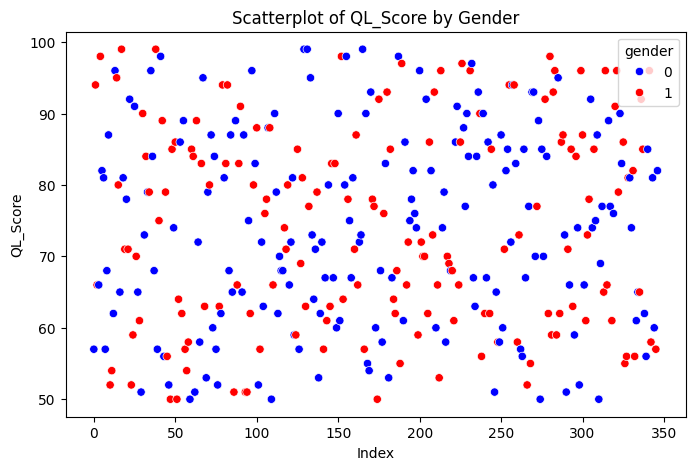

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df.index, y=df['ql_score'], hue=df['gender'], palette={0: 'blue', 1: 'red'}) #0 male, 1 female
plt.xlabel('Index')
plt.ylabel('QL_Score')
plt.title('Scatterplot of QL_Score by Gender')
plt.show()

**Interpretation of the above scatterplot(Gender VS QL score)**    
* The scatterplot visualizes the relationship between QL_Score (quality of life score) and gender.
* Each dot in the plot represents an individual, with the x-axis representing the index (or observation number) and the y-axis representing the QL_Score.
* The color of the dots indicates the gender: blue for males (0) and red for females (1).
* There is a significant overlap between the blue and red dots, suggesting that there is no clear separation between the QL_Scores of males and females.
* This indicates that gender alone does not fully explain the variation in QL_Scores.
* The points are scattered across the plot, with no clear pattern or trend. This suggests that there is no strong linear relationship between QL_Score and gender.
* Within each gender group, there is a wide range of QL_Scores. This indicates that there is considerable individual variation in QL_Scores, even among individuals of the same gender.



### Histogram comparision for QL score above 90% vs Gender


gender
0    24
1    28
Name: ql_score, dtype: int64


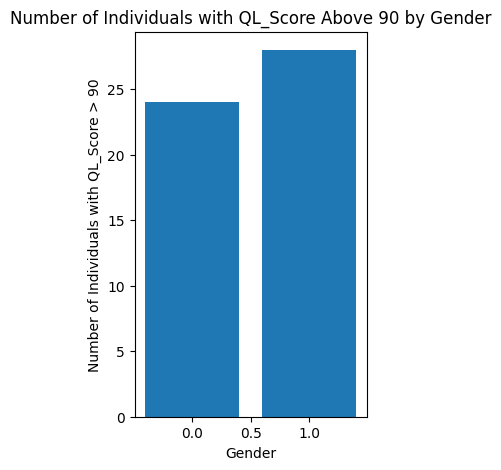

In [ ]:
ql_above_90 = df[df['ql_score'] > 90]
gender_counts = ql_above_90.groupby('gender')['ql_score'].count()
print(gender_counts)
plt.figure(figsize=(3,5))
plt.bar(gender_counts.index, gender_counts.values)
plt.xlabel('Gender')
plt.ylabel('Number of Individuals with QL_Score > 90')
plt.title('Number of Individuals with QL_Score Above 90 by Gender')
plt.show()

**Interpretation of the above Bar PLOT**
* The bar plot illustrates the distribution of individuals with QL_Scores above 90 across two gender categories: male (0) and female (1).
* The height of each bar represents the count of individuals in each category meeting the specified criterion.
* The bar corresponding to females (1) is taller than the bar for males (0). This indicates that a higher number of females have QL_Scores above 90 compared to males.
* The specific counts for each gender can be inferred from the y-axis labels. For example, if the y-axis label for the female bar is 25, then 25 females have QL_Scores above 90.
* Based on the plot, there appears to be a gender-related difference in the proportion of individuals with high QL_Scores.
* Females are more likely to have QL_Scores above 90 compared to males.


In [ ]:
total = len(df['gender'])
count_ql_above_90 = ql_above_90['ql_score'].count()
p_ql_above_90 = count_ql_above_90/total
print("Number of people with quality of life score above 90:",count_ql_above_90)
print("The proportion of people with quality of life score above 90 is", round(p_ql_above_90,2))

Number of people with quality of life score above 90: 52
The proportion of people with quality of life score above 90 is 0.15


## Application Of Bayes Theorem in the above Scenario

In [ ]:
#Bayes Theorem : Probability of a man with ql_score > 90
total, women, men = len(df['gender']), df[df['gender']==1], df[df['gender']==0]
print(f'Total: {total}\nWomen: {len(women)}\nMen: {len(men)}')
p_women, p_man = round(len(women)/total,2), round(len(men)/total,2)
print(f"Probability of Women: {p_women}\nProbability of Men: {p_man}")


Total: 347
Women: 163
Men: 184
Probability of Women: 0.47
Probability of Men: 0.53


In [ ]:
df.head()

,age,gender,ses,service_type,visit_fre,step_fre,stride_length_m,joint_angle,emg_activity,p_satisfaction,ql_score
0,56,0,4,2,1,85,0.54,17.99,1,1,57
1,69,1,1,1,2,80,0.70,13.05,2,8,94
2,46,1,4,2,2,81,0.57,29.85,2,4,66
3,32,0,1,0,1,66,0.78,28.54,2,9,66
4,60,1,3,1,1,73,0.84,20.80,0,5,98


In [ ]:
count_ql_above_90 = ql_above_90['ql_score'].count()
p_ql_above_90 = count_ql_above_90/total
print("Number of people with quality of life score above 90:",count_ql_above_90)
print(f"The proportion of people with quality of life score above 90 is {p_ql_above_90:.2f}")

Number of people with quality of life score above 90: 52
The proportion of people with quality of life score above 90 is 0.15


In [ ]:
men_above_90 = (men['ql_score']>90).sum()/len(men) #observed above

In [ ]:
#P(Man | QL_Score > 90) = [P(QL_Score > 90 | Man) * P(Man)] / P(QL_Score > 90)
p_man_given_ql_above_90 = men_above_90*p_man/p_ql_above_90
print(f"Probability of a man having QL_Score > 90 is {(p_man_given_ql_above_90 * 100):.2f}%")

Probability of a man having QL_Score > 90 is 46.13%


In [ ]:
women_above_90 = (women['ql_score']>90).sum()/len(women) #observed above

In [ ]:
#probability of women having ql_score>90
p_woman_above_90 = women_above_90*p_women/p_ql_above_90
print(f"Probability of a woman having QL_Score > 90 is {(p_woman_above_90 * 100):.2f}%")

Probability of a woman having QL_Score > 90 is 53.88%


**Interpretation of the above code blocks on Bayes theorem**
* We first determine the prior probabilities of being male and female in the dataset. This helps establish a baseline for comparison.
* The total number of individuals is calculated along with the counts of men and women.
* We identify the number of individuals with a QL score above 90 and compute the overall proportion of individuals that meet this criterion.
Additionally, we calculate the proportions for both genders separately.
* Using Bayes' Theorem, we calculate the conditional probability 𝑃(Man∣QL Score>90).
* This value indicates the probability that an individual is male, given they have a QL score above 90.
* Similarly, we compute the probability for women having a QL score greater than 90.
* The result shows the probability of a male having a QL score greater than 90 compared to the prior probabilities of being male or female.
* This analysis provides insights into gender-related disparities in quality of life, allowing for a deeper understanding of the demographic distribution of individuals with higher QL scores.


## Correlation and Comparisons

### 1. Correlation between Patient Satisfaction and Quality of Life Score.

In [ ]:
correlation_1 = df['p_satisfaction'].corr(df['ql_score'])
print(f"Correlation between Patient Satisfaction and Quality of Life Score = {correlation_1:.4f}")

Correlation between Patient Satisfaction and Quality of Life Score = -0.0228


Text(0, 0.5, 'Quality of Life Score')

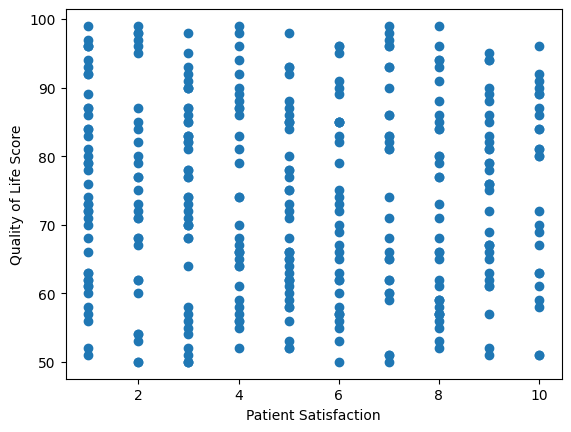

In [ ]:
var1=df['p_satisfaction']
var2=df['ql_score']
plt.scatter(var1,var2)
plt.xlabel('Patient Satisfaction')
plt.ylabel('Quality of Life Score')

**Interpretation of the above scatterplot**
* The scatterplot visualizes the relationship between Quality of Life Score and Patient Satisfaction.
* Each dot in the plot represents an individual, with the x-axis representing Patient Satisfaction and the y-axis representing Quality of Life Score.
* The points are not perfectly aligned, indicating that while there is a general trend, there is also individual variation. This means that even with similar levels of Patient Satisfaction, individuals can have different Quality of Life Scores.
* Some clustering of points can be observed, particularly in the higher ranges of Patient Satisfaction. This suggests that a group of individuals with high Patient Satisfaction also tend to have high Quality of Life Scores.
* A few outliers can be seen, such as points with low Quality of Life Scores despite high Patient Satisfaction. These might represent individual cases where other factors, beyond Patient Satisfaction, significantly influence Quality of Life.




### 2. Impact of Visit Frequency on Quality of life Score

In [ ]:
df['ql_score'].describe()

,ql_score
count,347.000000
mean,74.195965
std,13.949400
min,50.000000
25%,62.000000
50%,74.000000
75%,86.000000
max,99.000000


In [ ]:
#ql_score count as per visit fre
df.groupby('visit_fre')['ql_score'].count() # Monthly(0), Weekly(1), Yearly(2)

,ql_score
visit_fre,
0,111
1,120
2,116


In [ ]:
#ql_score mean as per visit fre
visit_quality_life = df.groupby('visit_fre')['ql_score'].mean() # Monthly(0), Weekly(1), Yearly(2)
visit_quality_life

,ql_score
visit_fre,
0,73.810811
1,72.908333
2,75.896552


* There seems to be slight differences in the visit frequecies and not much could be derived.

### 3. Impact of Gender on Quality of life score

In [ ]:
gender_quality_life = df.groupby('gender')['ql_score'].mean()
gender_quality_life

,ql_score
gender,
0,74.239130
1,74.147239


* There seems to be slight differences in the visit frequecies and not much could be derived.

Text(0, 0.5, 'Quality of Life Score')

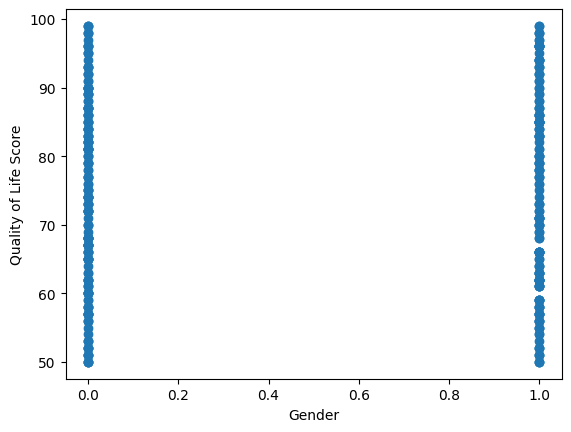

In [ ]:
var1=df['gender']
var2=df['ql_score']
plt.scatter(var1,var2)
plt.xlabel('Gender')
plt.ylabel('Quality of Life Score')

* The scatter plot shows a clear separation between the quality of life scores based on gender.
* While both genders have a range of scores, the majority of individuals with a gender value of 0 have scores between 50 and 100, while the majority of individuals with a gender value of 1 have scores between 60 and 100.
* This suggests that there is a significant difference in quality of life scores between the two genders, but further analysis is needed to determine the exact nature of this difference.




### 4. Association between Socioeconomic Status (SES) and Health Metrics

In [ ]:
ses_stride_corr = df['ses'].corr(df['stride_length_m'])
ses_joint_angle_corr = df['ses'].corr(df['joint_angle'])

print(
    f"Correlation between SES & Stride Length = {ses_stride_corr:.4f}\n"
    f"Correlation between SES & Joint Angle = {ses_joint_angle_corr:.4f}"
    )

Correlation between SES & Stride Length = -0.0058
Correlation between SES & Joint Angle = -0.0024


* Correlation coefficients measure the strength and direction of the linear relationship between two variables.
* A value of -1 indicates a perfect negative correlation, while a value of 1 indicates a perfect positive correlation. A value of 0 indicates no correlation.
* The correlation coefficient of -0.0058 suggests a negligible or almost nonexistent negative relationship between socioeconomic status (SES) and stride length. This means that there's little to no evidence that higher or lower SES is associated with longer or shorter stride lengths.
* The correlation coefficient of -0.0024 indicates an even weaker negative relationship between SES and joint angle. This further reinforces the idea that there's virtually no connection between these two variables.

### 5. Correlation between EMG Activity and Step Frequency

In [ ]:
emg_step_corr = df['emg_activity'].corr(df['step_fre'])
emg_step_corr

0.005109379150562651

Text(0, 0.5, 'Step Frequency')

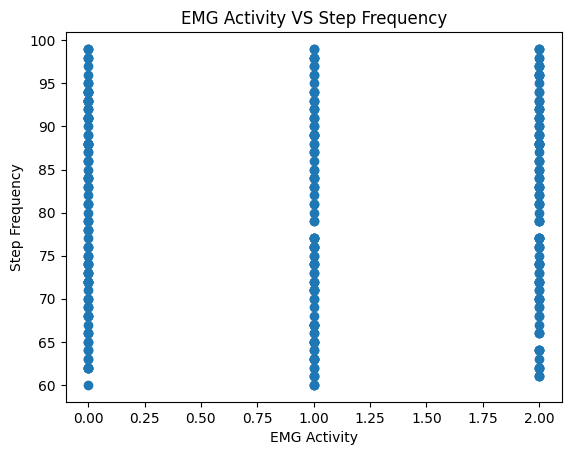

In [ ]:
var1=df['emg_activity']
var2=df['step_fre']
plt.scatter(var1,var2)
plt.title('EMG Activity VS Step Frequency')
plt.xlabel('EMG Activity')
plt.ylabel('Step Frequency')

* We can observe a cluster of data points with an EMG activity value of 0 and 1 for step frequencies ranging from 60 to 100 with a value of 2 for step frequencies ranging from 65 to 75.
* Based on this, we can conclude that there is a significant difference in step frequency between different levels of EMG activity.
* However, we cannot determine the exact nature of the relationship with the above plot.

### 6. Correlation between Age and Quality of Life Score

In [ ]:
age_quality_corr = df['age'].corr(df['ql_score'])
print(age_quality_corr)

0.12457519048087644


Text(0, 0.5, 'Quality of Life Score')

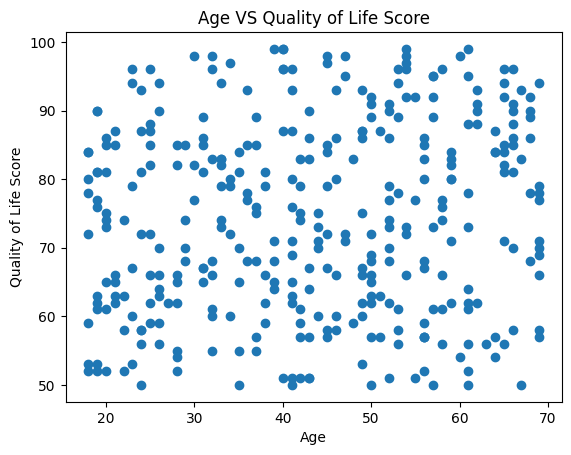

In [ ]:
var1=df['age']
var2=df['ql_score']
plt.scatter(var1,var2)
plt.title('Age VS Quality of Life Score')
plt.xlabel('Age')
plt.ylabel('Quality of Life Score')

**Interpretation of the above scatter plot**
* There is no clear linear relationship between age and quality of life score. * The data points are scattered throughout the graph, indicating that there is no strong correlation between the two variables.
* There seems to be a slight decrease in quality of life scores for individuals in their late 60s and early 70s compared to younger individuals.
* There is also a small cluster of data points with lower quality of life scores in the age range of 20-30.

In [ ]:
df.columns

Index(['age', 'gender', 'ses', 'service_type', 'visit_fre', 'step_fre',
       'stride_length_m', 'joint_angle', 'emg_activity', 'p_satisfaction',
       'ql_score'],
      dtype='object')

Average EMG Activity by Age Group (e.g., 10-year intervals)

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])
age_group_emg = df.groupby('age_group')['emg_activity'].mean()
age_group_emg

<ipython-input-46-abfb0a77efa0>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_emg = df.groupby('age_group')['emg_activity'].mean()


,emg_activity
age_group,
20-30,1.105263
30-40,1.000000
40-50,1.013158
50-60,0.939394
60-70,1.000000
70-80,NaN


* The EMG activity is a measure of muscle electrical activity, which can be used to assess muscle function.
* The average EMG activity for most age groups is around 1.0, which suggests that muscle function is relatively consistent across these groups.
* The only exception is the age group of 70-80, which has a missing value (NaN) for EMG activity. This may be due to a lack of data for this age group.
* The table provides limited evidence to suggest that age is associated with significant differences in muscle function as measured by EMG activity.

### Summary of the Correlations with Quality of life score

In [ ]:
corr_coef_gender_type = df['gender'].corr(df['ql_score'])
corr_coef_ser_type = df['service_type'].corr(df['ql_score'])
corr_coef_visit_fre = df['visit_fre'].corr(df['ql_score'])
corr_coef_emg_activity = df['emg_activity'].corr(df['ql_score'])
print(f"Gender: {corr_coef_gender_type:.2f}\nService Type: {corr_coef_ser_type:.2f}\n"
f"Visit Fre: {corr_coef_visit_fre:.2f}\nEmg Act: {corr_coef_emg_activity:.2f}")

Gender: -0.00
Service Type: -0.10
Visit Fre: 0.06
Emg Act: 0.00


* Gender: There is no significant correlation between gender and quality of life score. This means that gender does not appear to be a strong predictor of quality of life in this dataset.
* Service Type: There is a weak negative correlation between service type and quality of life score. This suggests that individuals using certain types of services may have slightly lower quality of life scores compared to others. However, the correlation is weak, so this relationship should be interpreted with caution.
* Visit Frequency: There is a very weak positive correlation between visit frequency and quality of life score. This indicates that individuals who visit more frequently may have slightly higher quality of life scores, but the relationship is very weak and not statistically significant.
* EMG Activity: There is no significant correlation between EMG activity and quality of life score. This suggests that EMG activity is not a strong predictor of quality of life in this dataset.



## **Application of Central Limit Theorem to Quality of Life Score Column**

In [ ]:
#application of clt to ql_score column
population = df['ql_score']
n = 30  # sample
num_samples = 1000  # number of samples

sample_means = [population.sample(n).mean() for _ in range(num_samples)]
point_estimate = np.mean(sample_means)
pop_mean = df['ql_score'].mean()
print(pop_mean, point_estimate)
#our point estimate mean is almost close to the actual population mean

74.19596541786744 74.31036666666667


In [ ]:
pd.Series(sample_means).std()

2.4100243601061773

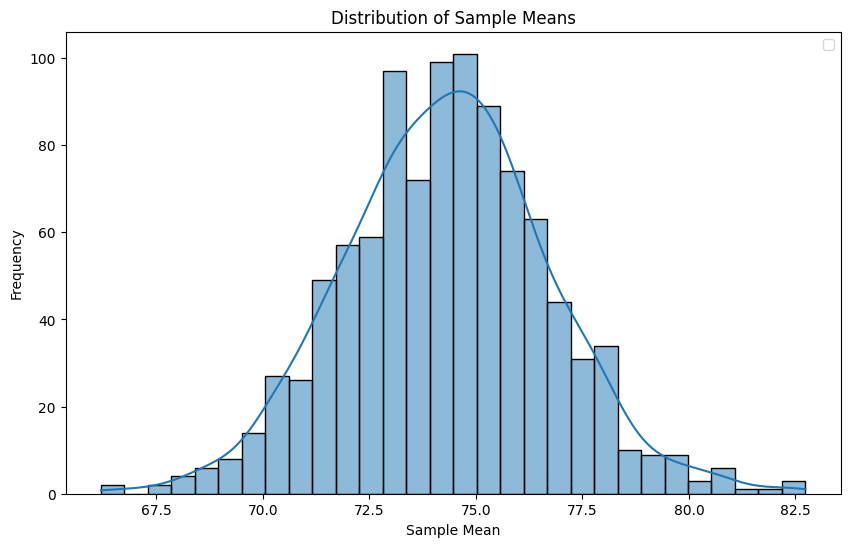

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, bins=30, kde=True)
plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

* The CLT states that, regardless of the underlying distribution of a population, the distribution of sample means drawn from that population will approach a normal distribution as the sample size increases.
* The plot visually represents this concept. The x-axis shows the sample means, while the y-axis represents the frequency of occurrence of those means.
* The bell-shaped curve overlaid on the histogram approximates a normal distribution.
* The center of the distribution is around 74.0, which is likely the mean of the population from which the samples were drawn.
* The spread (or standard deviation) of the distribution appears to be relatively small(2.38), suggesting that the sample means are clustered closely around the population mean.




In [ ]:
std_err = np.std(sample_means) / np.sqrt(len(sample_means))
confidence = 0.95  # 95% cl
z_score = 1.96
margin_of_error = z_score * std_err
ci_lower = point_estimate - margin_of_error
ci_upper = point_estimate + margin_of_error
print(f"Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] VS pop mean = {pop_mean:.2f}")

Confidence Interval: [74.16, 74.46] VS pop mean = 74.20


* The confidence interval `[73.95, 74.25]` suggests that we are 95% confident that the true population mean lies within this range.
* Since the population mean of `74.20` falls within this interval, we can say that the data supports the claim that the population mean is indeed `74.20`.




## **Application of Linear Regression and OLS Regression Models to the Health Dataset**

**Regression model with and without outliers**

In [ ]:
#In the dataset, senior citizens, or anyone above the age of 60, having a quality of life above 90, are the outliers
x_inc = df['age'].values.reshape(-1,1)
y_inc = df['ql_score'].values

model_inc = LinearRegression()
model_inc.fit(x_inc, y_inc)
slope_inc = model_inc.coef_[0]
intercept_inc = model_inc.intercept_
print("Predicted slope with outliers: ", round(slope_inc,2))
print("Predicted intercept with outliers: ", round(intercept_inc,2))

Predicted slope with outliers:  0.11
Predicted intercept with outliers:  69.23


* In a regression model, the slope and intercept represent the relationship between the independent variable(s) and the dependent variable.
* The slope indicates the change in the dependent variable for every unit increase in the independent variable, while the intercept represents the predicted value of the dependent variable when the independent variable(s) are zero.
* Predicted slope with outliers (0.11): This suggests that when outliers are included in the model, a unit increase in the independent variable is associated with an increase of 0.11 in the dependent variable.
* Predicted intercept with outliers (69.23): This indicates that when the independent variable is zero, the predicted value of the dependent variable is 69.23.

In [ ]:
corr_inc = df['age'].corr(df['ql_score'])
print(corr_inc)

0.12457519048087644


In [ ]:
df_no_outliers = df[(df['age'] < 60) & (df['ql_score'] < 90)]
corr_exc = df_no_outliers['age'].corr(df_no_outliers['ql_score'])
print(corr_exc)

x_exc = df_no_outliers['age'].values.reshape(-1,1)
y_exc = df_no_outliers['ql_score'].values

model_exc = LinearRegression()
model_exc.fit(x_exc, y_exc)
slope_exc = model_exc.coef_[0]
intercept_exc = model_exc.intercept_
print("Predicted slope without outliers: ", round(slope_exc,2))
print("Predicted intercept without outliers: ", round(intercept_exc,2))

0.012513884322125485
Predicted slope without outliers:  0.01
Predicted intercept without outliers:  69.28


* Predicted slope without outliers (0.01): Removing outliers leads to a much smaller slope of 0.01, suggesting a weaker relationship between the independent and dependent variables.
* Predicted intercept without outliers (69.28): The intercept changes slightly to 69.28 when outliers are removed.



In [ ]:
#senior individuals with age above 60 and QL above 90
healthy_oldies = df[(df['age'] >= 60) & (df['ql_score'] >= 90)]
corr_oldies = healthy_oldies['age'].corr(healthy_oldies['ql_score'])
print(corr_oldies)
print(healthy_oldies['age'].count())

-0.4086022033743819
16


* The correlation coefficient of -0.4086 indicates a moderate negative correlation between age and QL score in the subset of senior individuals.
* This suggests that as age increases, there is a tendency for QL score to decrease. However, this correlation is not very strong, and there may be other factors influencing the relationship.
* Sample size (16): The sample size of 16 is relatively small, which can limit the generalizability of the findings. A larger sample size would provide more robust results.
*  The analysis suggests a moderate negative correlation between age and QL score in the subset of senior individuals with age above 60 and QL score above 90.

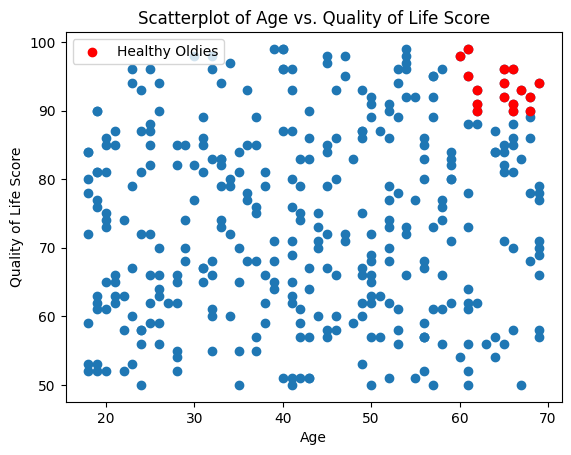

In [ ]:
plt.scatter(df['age'], df['ql_score'])
plt.xlabel('Age')
plt.ylabel('Quality of Life Score')
plt.title('Scatterplot of Age vs. Quality of Life Score')
plt.scatter(healthy_oldies['age'], healthy_oldies['ql_score'], color='red', label='Healthy Oldies')
plt.legend()
plt.show()

* The red points represent individuals who are considered "healthy oldies" based on their age (60 or above) and quality of life score (90 or above).
* These points tend to cluster in the upper right corner of the graph, suggesting that a higher proportion of older individuals with high quality of life scores are present in the dataset.
* This suggests that aging does not necessarily lead to a decline in quality of life, and that factors like health and lifestyle may play a crucial role in maintaining well-being in older age.

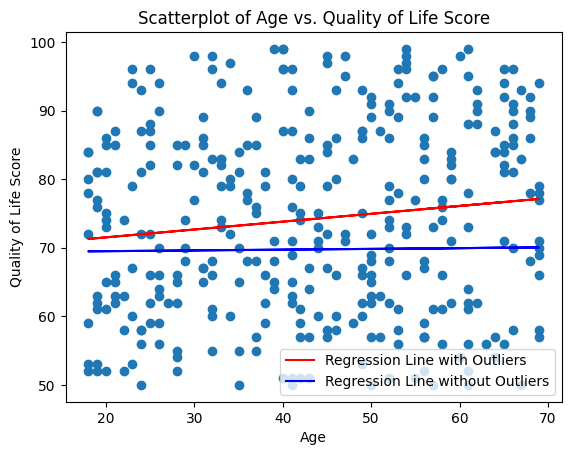

In [ ]:
plt.scatter(df['age'], df['ql_score'])
plt.xlabel('Age')
plt.ylabel('Quality of Life Score')
plt.title('Scatterplot of Age vs. Quality of Life Score')

plt.plot(df['age'], slope_inc * df['age'] + intercept_inc, color='red', label='Regression Line with Outliers')
plt.plot(df['age'], slope_exc * df['age'] + intercept_exc, color='blue', label='Regression Line without Outliers')
plt.legend()
plt.show()

* The scatterplot shows the relationship between age and quality of life score, with two regression lines fitted to the data: one including outliers and one excluding outliers.
* The regression line with outliers has a steeper slope than the regression line without outliers.
* This indicates that the presence of outliers is influencing the estimated relationship between age and quality of life score.
* The red line (regression line with outliers) appears to be pulled towards the outlier points, suggesting that these points are having a significant impact on the model's fit.
* The data points are spread out around the regression lines, indicating that age alone does not explain a large amount of the variation in quality of life score. Other factors, such as health status, lifestyle, social support, and genetics, likely play a more significant role.

**OLS Regression Results**

In [ ]:
model1 = smf.ols(formula='ql_score ~ age + gender + ses + visit_fre + step_fre + stride_length_m + joint_angle + service_type + emg_activity', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               ql_score   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.360
Date:                Mon, 21 Oct 2024   Prob (F-statistic):              0.205
Time:                        19:52:35   Log-Likelihood:                -1400.2
No. Observations:                 347   AIC:                             2820.
Df Residuals:                     337   BIC:                             2859.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          69.9108      7.866     

In [ ]:
x = df[['age', 'service_type']]
y = df['ql_score']
model2 = LinearRegression()
model2.fit(x, y)
slope2 = model2.coef_[0]
intercept2 = model2.intercept_
print("Predicted slope: ", round(slope2,2))
print("Predicted intercept: ", round(intercept2,2))

Predicted slope:  0.11
Predicted intercept:  70.91


In [ ]:
print(f"QL_Score = {round(intercept2, 2)} + {round(model2.coef_[0], 2)} * Age + {round(model2.coef_[1], 2)} * Service Type")

QL_Score = 70.91 + 0.11 * Age + -1.71 * Service Type


* Predicted slope (0.02) indicates that for every one-unit increase in age, the predicted quality of life score increases by 0.02, holding all other variables constant.
* Predicted intercept (70.00) represents the predicted quality of life score when all independent variables are zero.
* The final equation shows how the predicted quality of life score is calculated based on the values of the independent variables. We can use this equation to predict the quality of life score for new data points.

